# **Early Identification of At-Risk Students**

## **A Business Analytics Case Study for Educational Decision Support**

---

# Table of Contents

1.  Project Overview
2.  Business Problem
3.  Stakeholder Analysis
4.  Project Objective
5.  Dataset Description
6.  Project Definition
7.  Business Questions
#  
8.  Data Loading
9.  Data Understanding
#  
10. Exploratory Data Analysis
11. Correlation Analysis
#
12. Linear Regression
13. Feature Selection
14. Final Regression Model
#
15. Predictive Modeling
#
16. Model Comparison
17. Business Insights
18. Recommendations
19. Executive Summary

# **1.  Project Overview**


Student academic performance is influenced by various factors, including study habits, past academic records, family background, and lifestyle. However, schools often identify students who are struggling only after their final grades are released, limiting the opportunity for timely intervention.

This project aims to analyze historical student performance data to identify the key factors associated with poor academic performance and support the early identification of at-risk students. In this project, students with a final grade (G3) below 12 are defined as at-risk students.

The insights generated from this analysis are intended to support school decision-makers in developing earlier and more targeted intervention strategies to improve student learning outcomes.

# **2. Business Problem**



Schools often identify students with poor academic performance only after final grades are released. By that stage, opportunities for timely intervention may already have been missed.

The core challenge is not simply to determine which students performed poorly, but to identify students who are at risk before academic difficulties become severe.

This project explores whether historical student data can be used to identify at-risk students earlier, enabling school decision-makers to implement timely support strategies and improve student outcomes.

# **3. Stakeholder**

| Stakeholder | Needs | Decision | How This Project Helps |
|-------------|-------|----------|------------------------|
| School Principal | Improve overall student performance and allocate educational resources effectively. | Determine how to allocate school resources and prioritize intervention programs. | Identify at-risk students early and support data-driven educational decisions. |
| Teachers | Identify students who may require additional academic support before their performance declines further. | Decide which students need closer monitoring, tutoring, or academic guidance. | Highlight key risk factors associated with poor academic performance and support early intervention. |
| Academic Affairs Office | Develop effective academic support programs and improve student success rates. | Plan academic warning systems and targeted support programs. | Provide data-driven insights to design more effective intervention strategies. |

# **4. Project Objective**


The primary objective of this project is to identify the key factors associated with poor academic performance and develop a data-driven approach for the early identification of at-risk students.

Specifically, this project aims to:

- Analyze the relationships between student characteristics and academic performance.
- Identify the factors most strongly associated with poor final grades.
- Support the early identification of at-risk students using historical student data.
- Provide actionable insights and recommendations to support educational decision-making.

# **5. Dataset Description**


This project uses the Student Performance dataset from the UCI Machine Learning Repository. The dataset contains demographic, family, academic, and lifestyle information for secondary school students, along with their final academic performance (G3).

The dataset is used to explore factors associated with student performance and support data-driven educational decision-making.

# **6. Project Definition**



For the purpose of this project, students with a final grade (G3) below 12 are classified as at-risk students.

This threshold is defined by the project to represent students who may require additional academic support. It serves as the basis for subsequent exploratory analysis, predictive modeling, and business recommendations.

# **7. Business Questions**



1. Which factors are most strongly associated with poor academic performance?

2. How do study habits, attendance, and previous academic failures relate to students' final grades?

3. Can historical student data be used to identify at-risk students before the end of the semester?

4. Which groups of students should be prioritized for early intervention?

5. What insights can help schools design earlier and more effective intervention strategies?

These business questions serve as the foundation of the exploratory data analysis (EDA) and guide the subsequent modeling and business recommendations throughout this project.

# **8.Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("student-por.csv")

# **9. Data Understanding**

In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
df.shape

(649, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [ ]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


### Data Understanding Summary

**Dataset Quality**
- 649 observations and 33 variables.
- No missing values were detected.

**Initial Findings**
- The dataset contains both numerical and categorical variables.
- Most students have no previous failures.
- Student study time is concentrated in the lower categories.
- `absences` appears to be right-skewed and may contain outliers.

**Next Step**
Perform Exploratory Data Analysis (EDA) to validate these observations using visualizations and correlation analysis.

# **10. 第一版EDA**

## Study Time

In [ ]:
df.groupby('studytime')['G3'].agg(['count', 'mean', 'max', 'min'])

,count,mean,max,min
studytime,,,,
1,212,10.844340,18,0
2,305,12.091803,19,0
3,97,13.226804,18,8
4,35,13.057143,19,6


**Fact**

* The average final grade (G3) increased from 10.84 to 13.23 as studytime increased from level 1 to level 3.
* Students in studytime = 4 had a slightly lower average G3 (13.06) than those in studytime = 3 (13.23).
* Approximately 80% of students were in studytime levels 1 or 2.
* The studytime = 4 group had the smallest sample size (35 students).

**Inference**

Students with studytime levels 2 and 3 generally achieved higher average final grades than those in level 1. However, the studytime = 4 group had a relatively small sample size, and its average grade was only 0.17 points lower than the studytime = 3 group. Therefore, the current results do not support the conclusion that studying longer always leads to better academic performance. Further analyses are required to determine whether study time remains associated with final grades after controlling for other variables.

## Previous Academic Failures

In [ ]:
df.groupby('failures')['G3'].agg(['count','mean','max','min'])

,count,mean,max,min
failures,,,,
0,549,12.510018,19,0
1,70,8.642857,16,0
2,16,8.812500,15,0
3,14,8.071429,11,0


**Fact**

* Students with no previous academic failures (failures = 0) achieved the highest average final grade (12.51).

* Students with one or more previous failures (failures
= 1–3) had average final grades ranging from 8.07 to 8.81.
* The average grade difference between students with no previous failures and those with at least one previous failure was approximately 3.7–4.4 points.
* The failures = 2 and failures = 3 groups had relatively small sample sizes (16 and 14 students), so their results should be interpreted with caution.

**Inference**

Students with at least one previous academic failure tended to achieve lower final grades than those without any previous failures. Previous academic failures may serve as an indicator of students at higher academic risk rather than a direct cause of poor academic performance. However, because the sample sizes for the failures = 2 and failures = 3 groups are relatively small, additional analyses are required before drawing stronger conclusions. Further correlation and regression analyses are needed to determine whether this relationship remains significant after controlling for other variables.

## Absence Group

In [ ]:
df.groupby('absences')['G3'].agg(['count', 'mean', 'max', 'min'])

,count,mean,max,min
absences,,,,
0,244,12.040984,19,0
1,12,12.416667,16,10
2,110,12.190909,18,6
3,7,10.428571,17,7
4,93,12.010753,19,6
5,12,11.750000,17,8
6,49,12.122449,17,8
7,3,13.000000,16,8
8,42,11.619048,16,7


**Data Transformation**

The original grouping of absences produced too many categories, and several groups contained only one or two observations. Such small sample sizes make the average values unstable and difficult to interpret from a business perspective. Therefore, the absences variable was regrouped into four business-friendly categories (0, 1–4, 5–9, and 10+ absences) for further analysis.

In [ ]:
df['absence_group'] = pd.cut(
    df['absences'],
    bins=[-1, 0, 4, 9, df['absences'].max()],
    labels=['0', '1-4', '5-9', '10+']
)

df.groupby('absence_group')['G3'].agg(['count', 'mean', 'max', 'min'])

/tmp/ipykernel_789/439372017.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('absence_group')['G3'].agg(['count', 'mean', 'max', 'min'])


,count,mean,max,min
absence_group,,,,
0,244,12.040984,19,0
1-4,222,12.072072,19,6
5-9,113,11.769912,17,7
10+,70,11.128571,18,5


**Fact**

* Students with 0 and 1–4 absences had similar average final grades (12.04 and 12.07).
* Students with 5–9 absences had a lower average final grade (11.77), while those with 10 or more absences had the lowest average final grade (11.13).
* In addition, the number of students decreased as the absence category increased.

**Inference**

Students with 5 or more absences tended to achieve lower final grades than students with fewer absences, suggesting that frequent absences may be associated with poorer academic performance. However, further analyses are required to determine whether absences remain an important predictor of final grades after controlling for other variables.

## Higher Education

In [ ]:
df['higher'].value_counts()

,count
higher,
yes,580
no,69


In [ ]:
higher_analysis = (
    df.groupby('higher')['G3']
      .agg(['count', 'mean', 'min', 'max'])
      .round(2)
)

higher_analysis

,count,mean,min,max
higher,,,,
no,69,8.80,0,14
yes,580,12.28,0,19


**Fact**

* 580 students planned to pursue higher education, while 69 students did not.
* Students planning to pursue higher education had an average final grade of 12.28, compared with 8.80 for students who did not.
* 1Both groups had students who scored 0, while the maximum final grade was 19 for the higher education group and 14 for the non-higher education group.

**Inference**

Students who planned to pursue higher education tended to achieve higher final grades. This pattern suggests that stronger educational aspirations may be associated with better academic performance and may also reflect greater academic motivation among these students.


## School Support

In [ ]:
df['schoolsup'].value_counts()

,count
schoolsup,
no,581
yes,68


In [ ]:
schoolsup_analysis = (
    df.groupby('schoolsup')['G3']
      .agg(['count', 'mean', 'min', 'max'])
      .round(2)
)

schoolsup_analysis

,count,mean,min,max
schoolsup,,,,
no,581,11.98,0,19
yes,68,11.28,0,18


**Fact**

* 68 students received school support, while 581 students did not.
* Students who received school support had an average final grade of 11.28, compared with 11.98 for those who did not, a difference of only 0.70 points.
* The maximum final grade was 18 for students with school support and 19 for those without support.

**Inference**

Students who received school support showed slightly lower average final grades. This pattern does not necessarily indicate that school support is ineffective, as students receiving additional support may already face greater academic challenges.

## Family Educational Background

### Mother's Education

In [ ]:
medu_analysis = (
    df.groupby('Medu')['G3']
      .agg(['count','mean','min','max'])
      .round(2)
)

medu_analysis

,count,mean,min,max
Medu,,,,
0,6,11.67,10,15
1,143,10.80,0,18
2,186,11.66,0,18
3,139,11.92,0,19
4,175,13.07,0,19


### Father's Education

In [ ]:
fedu_analysis = (
    df.groupby('Fedu')['G3']
      .agg(['count','mean','min','max'])
      .round(2)
)

fedu_analysis

,count,mean,min,max
Fedu,,,,
0,7,12.14,10,18
1,174,10.94,0,19
2,209,11.78,0,18
3,131,12.38,1,18
4,128,12.92,0,19


**Fact**

* Students whose mothers had the highest education level (Level 4) achieved the highest average final grade (13.07), while those with education level 1 had the lowest average (10.80).
* A similar pattern was observed for fathers' education. Students whose fathers had the highest education level (Level 4) achieved the highest average final grade (12.92), whereas education level 1 had the lowest average (10.94).
* The Level 0 groups for both mothers (n = 6) and fathers (n = 7) contained relatively few observations, making their average grades less representative.

**Inference**

Students whose parents had higher education levels generally tended to achieve better academic performance. Although the relationship was not perfectly linear, both maternal and paternal education showed a similar overall pattern, suggesting that
parental education may be associated with students' academic achievement.

## EDA Summary

### Key Findings

1. Previous academic failures showed the strongest relationship with final grades among all variables examined.

2. Students planning to pursue higher education and those with more highly educated parents generally achieved better academic performance.

3. Study time showed a generally positive relationship with final grades, although the pattern was not perfectly linear.

4. Frequent absences were associated with lower academic performance, but the relationship appeared relatively modest.

5. School support alone showed little difference in average final grades and should not be interpreted as evidence that academic support is ineffective.

### Business Implications

The exploratory analysis suggests that previous academic failures appear to be the strongest indicator of poor academic performance among the variables examined. Educational aspirations and parental education also showed meaningful relationships with final grades, while study time and absences demonstrated weaker or less consistent patterns. School support alone showed little difference in average academic performance and should not be interpreted as evidence of ineffectiveness, as students receiving support may already face greater academic challenges.

### Next Step

While the EDA identified several potentially important factors, exploratory analysis alone cannot determine which variables remain significant after accounting for others. Therefore, the next step is to perform correlation analysis and regression modeling to evaluate the strength and independence of each factor's relationship with final grades.

# 11. Correlation Analysis

## Correlation Matrix

In [ ]:
# Prepare data for correlation analysis

correlation_data = df.drop(columns=['G1', 'G2']).copy()

categorical_features = correlation_data.select_dtypes(
    include=['object', 'category']
).columns

correlation_data = pd.get_dummies(
    correlation_data,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

correlation_data.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,absence_group_1-4,absence_group_5-9,absence_group_10+
0,18,4,4,2,2,0,4,3,4,1,...,0,0,0,1,1,0,0,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,1,0,0,0,1,1,0,1,0,0
2,15,1,1,1,2,0,4,3,2,2,...,0,0,0,1,1,1,0,0,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,1,1,1,1,1,0,0,0
4,16,3,3,1,2,0,4,3,2,1,...,1,0,0,1,1,0,0,0,0,0


In [ ]:
correlation_matrix = correlation_data.corr()

g3_correlations = (
    correlation_matrix['G3']
    .drop('G3')
    .sort_values(key=abs, ascending=False)
)

g3_correlations

,G3
failures,-0.393316
higher_yes,0.332172
school_MS,-0.284294
studytime,0.249789
Medu,0.240151
Fedu,0.211800
Dalc,-0.204719
Walc,-0.176619
reason_reputation,0.170944
address_U,0.167637


## Heatmap

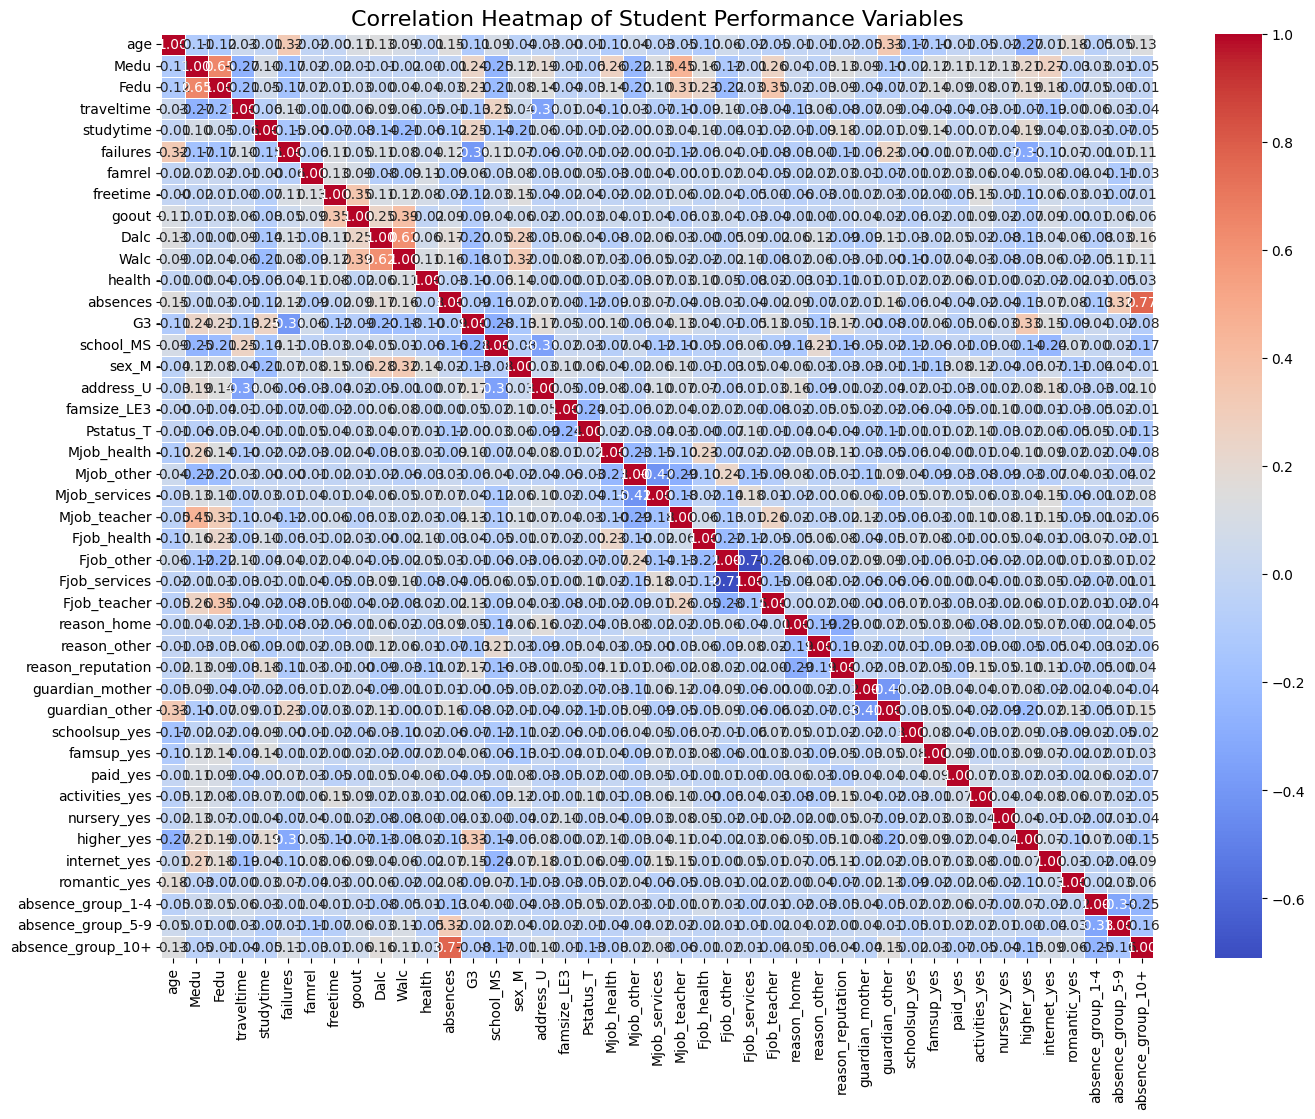

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Performance Variables", fontsize=16)

plt.show()

## Key Findings

The correlation analysis generally supports the patterns identified during the EDA. Previous academic failures exhibited the strongest negative correlation with final grades, reinforcing the observation that students with a history of academic failure consistently performed worse across multiple analytical approaches. This suggests that previous failures may serve as an effective indicator for identifying academically at-risk students.

In contrast, study time and absences demonstrated relatively weak linear relationships with final grades. These findings imply that academic performance is unlikely to be explained by a single behavioural factor alone and is more likely influenced by multiple academic and personal characteristics acting together.

Although higher education aspirations and parental education levels showed positive correlations with final grades, correlation analysis alone cannot determine whether these relationships remain significant after accounting for other variables. Therefore, further analysis is required before drawing conclusions about their independent effects.

## Summary

Overall, the correlation analysis successfully validated the key patterns identified during the EDA and strengthened confidence in the initial observations. However, because correlation analysis evaluates variables individually, it cannot determine the independent contribution of each factor when multiple variables are considered simultaneously.

The next step is to apply multiple linear regression to identify the variables that remain significant after controlling for other factors, providing stronger evidence to support educational decision-making and intervention strategies.

# 12. Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split

X = correlation_data.drop(columns=["G3", "absences"])
y = correlation_data["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (519, 41)
Testing set: (130, 41)


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("Intercept:", linear_model.intercept_)
print("Number of coefficients:", len(linear_model.coef_))

Intercept: 10.474091993759435
Number of coefficients: 41


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

MAE: 2.215
RMSE: 2.915
R²: 0.128


In [ ]:
coef_df = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Coefficient": linear_model.coef_
    })
    .sort_values(by="Coefficient", ascending=False)
)

coef_df

,Feature,Coefficient
35,higher_yes,1.604823
17,Mjob_health,1.097246
29,guardian_other,0.547784
20,Mjob_teacher,0.528995
19,Mjob_services,0.448236
4,studytime,0.400474
36,internet_yes,0.323975
39,absence_group_5-9,0.318406
14,address_U,0.300892
27,reason_reputation,0.299658


In [ ]:
print("Top 10 Positive Coefficients")
display(coef_df.head(10))

print("Top 10 Negative Coefficients")
display(coef_df.tail(10))

Top 10 Positive Coefficients


,Feature,Coefficient
35,higher_yes,1.604823
17,Mjob_health,1.097246
29,guardian_other,0.547784
20,Mjob_teacher,0.528995
19,Mjob_services,0.448236
4,studytime,0.400474
36,internet_yes,0.323975
39,absence_group_5-9,0.318406
14,address_U,0.300892
27,reason_reputation,0.299658


Top 10 Negative Coefficients


,Feature,Coefficient
22,Fjob_other,-0.392799
24,Fjob_teacher,-0.486033
13,sex_M,-0.501122
40,absence_group_10+,-0.677037
26,reason_other,-0.739996
23,Fjob_services,-0.956550
21,Fjob_health,-1.072947
12,school_MS,-1.391838
5,failures,-1.519398
30,schoolsup_yes,-1.570077


In [ ]:
import statsmodels.api as sm

In [ ]:
X_train_sm = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_sm).fit()

In [ ]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     7.435
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           7.67e-31
Time:                        07:13:30   Log-Likelihood:                -1219.0
No. Observations:                 519   AIC:                             2522.
Df Residuals:                     477   BIC:                             2701.
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.4741      2.22

### Key Findings

- `failures` was negatively associated with final grades and remained statistically significant after controlling for other variables.
- `studytime` and `higher_yes` showed significant positive associations with final grades.
- Parental education showed positive patterns in the EDA but was not statistically significant in the multiple regression model, suggesting limited independent explanatory value after controlling for other factors.

### Model Limitation

The model showed limited predictive performance (MAE = 2.215, RMSE = 2.915, R² = 0.128), indicating that the available variables explain only a small proportion of the variation in final grades. The results are therefore used mainly for identifying associations rather than making precise predictions or causal claims.

# 13. Feature Selection

In [ ]:
feature_selection = (
    pd.DataFrame({
        "Feature": ols_model.params.index,
        "Coefficient": ols_model.params.values,
        "P-value": ols_model.pvalues.values
    })
    .sort_values("P-value")
)

feature_selection

,Feature,Coefficient,P-value
6,failures,-1.519398,2.178355e-10
0,const,10.474092,3.238816e-06
13,school_MS,-1.391838,5.256609e-06
31,schoolsup_yes,-1.570077,1.320232e-04
36,higher_yes,1.604823,1.544006e-04
5,studytime,0.400474,1.242262e-02
12,health,-0.216950,1.250911e-02
24,Fjob_services,-0.956550,7.010593e-02
18,Mjob_health,1.097246,7.566614e-02
14,sex_M,-0.501122,7.624457e-02


In [ ]:
feature_selection[feature_selection["P-value"] < 0.05]

,Feature,Coefficient,P-value
6,failures,-1.519398,2.178355e-10
0,const,10.474092,3.238816e-06
13,school_MS,-1.391838,5.256609e-06
31,schoolsup_yes,-1.570077,1.320232e-04
36,higher_yes,1.604823,1.544006e-04
5,studytime,0.400474,1.242262e-02
12,health,-0.216950,1.250911e-02


### Feature Selection Results
#### Business Consideration

Among the statistically significant variables, `failures`, `studytime`, `higher_yes`, and `health` were retained because they are relevant to early identification and intervention.

`school_MS` was excluded because it is a background characteristic rather than an actionable intervention factor. `schoolsup_yes` was excluded because it may reflect students who had already received support rather than an early warning signal.

Although `absence_group` was directly related to the attendance-focused business question, it was not retained in the final model because it did not show a statistically significant independent association after controlling for other variables.

In [ ]:
selected_features = [
    "failures",
    "studytime",
    "higher_yes",
    "health"
]

pd.DataFrame({
    "Selected Feature": selected_features
})

,Selected Feature
0,failures
1,studytime
2,higher_yes
3,health


# 14. Final Regression Model

In [ ]:
X_final = correlation_data[selected_features]
y_final = correlation_data["G3"]

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train_final.shape)
print("Testing set:", X_test_final.shape)

Training set: (519, 4)
Testing set: (130, 4)


In [ ]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(X_train_final, y_train_final)

y_pred_final = final_model.predict(X_test_final)

print("Intercept:", final_model.intercept_)
print("Number of coefficients:", len(final_model.coef_))

Intercept: 9.70968065344759
Number of coefficients: 4


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_final, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
r2 = r2_score(y_test_final, y_pred_final)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

MAE: 2.141
RMSE: 2.8
R²: 0.196


In [ ]:
coef_final = (
    pd.DataFrame({
        "Feature": X_train_final.columns,
        "Coefficient": final_model.coef_
    })
    .sort_values(by="Coefficient", ascending=False)
)

coef_final

,Feature,Coefficient
2,higher_yes,2.155881
1,studytime,0.644250
3,health,-0.190090
0,failures,-1.719742


In [ ]:
import statsmodels.api as sm

X_train_final_sm = sm.add_constant(X_train_final)

ols_final = sm.OLS(y_train_final, X_train_final_sm).fit()

print(ols_final.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.241
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     40.72
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           1.18e-29
Time:                        07:13:30   Log-Likelihood:                -1275.8
No. Observations:                 519   AIC:                             2562.
Df Residuals:                     514   BIC:                             2583.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.7097      0.568     17.080      0.0

### Key Findings

- Previous academic failures remained the strongest negative predictor of final grades.
- Students with longer study time and aspirations for higher education tended to achieve higher academic performance.
- Health remained statistically significant, although its negative association was counterintuitive and should be interpreted cautiously because it may reflect unobserved factors not captured in the dataset.

| Metric           |  Full | Final |
| ---------------- | ----: | ----: |
| Features         |    41 |     4 |
| MAE              | 2.215 | 2.141 |
| RMSE             | 2.915 | 2.800 |
| R²               | 0.128 | 0.196 |
| Interpretability |   Low |  High |


The final regression model reduced the number of predictors from 41 to 4 while slightly improving predictive performance. Although the model still explained a limited proportion of the variance (R² = 0.196), it retained statistically significant and business-relevant predictors, making it more suitable for interpretation and decision support.

# 15 Predictive Modeling

Logistic Regression

In [ ]:
df["at_risk"] = df["G3"] <= 12

In [ ]:
df["at_risk"].value_counts()

,count
at_risk,
True,373
False,276


In [ ]:
df["at_risk"].value_counts(normalize=True)

,proportion
at_risk,
True,0.57473
False,0.42527


In [ ]:
X = df[["failures", "studytime", "higher", "health"]].copy()

X["higher"] = X["higher"].map({
    "yes": 1,
    "no": 0
})

y = df["at_risk"].astype(int)

In [ ]:
X.head()
X.dtypes

,0
failures,int64
studytime,int64
higher,int64
health,int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_precision = precision_score(y_test, y_pred)
logistic_recall = recall_score(y_test, y_pred)
logistic_f1 = f1_score(y_test, y_pred)

print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6692307692307692
Precision: 0.7142857142857143
Recall: 0.684931506849315
F1-score: 0.6993006993006993

Confusion Matrix:
[[37 20]
 [23 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63        57
           1       0.71      0.68      0.70        73

    accuracy                           0.67       130
   macro avg       0.67      0.67      0.67       130
weighted avg       0.67      0.67      0.67       130



In [ ]:
model.predict_proba(X_test)

array([[5.85600760e-01, 4.14399240e-01],
       [4.94709999e-01, 5.05290001e-01],
       [6.29318200e-01, 3.70681800e-01],
       [5.85600760e-01, 4.14399240e-01],
       [4.49016460e-01, 5.50983540e-01],
       [6.14774315e-01, 3.85225685e-01],
       [5.40492080e-01, 4.59507920e-01],
       [6.01205393e-04, 9.99398795e-01],
       [4.94709999e-01, 5.05290001e-01],
       [4.49016460e-01, 5.50983540e-01],
       [6.84067486e-01, 3.15932514e-01],
       [3.33314472e-01, 6.66685528e-01],
       [6.97283442e-01, 3.02716558e-01],
       [5.70512215e-01, 4.29487785e-01],
       [5.70512215e-01, 4.29487785e-01],
       [6.29318200e-01, 3.70681800e-01],
       [4.49016460e-01, 5.50983540e-01],
       [2.12139460e-01, 7.87860540e-01],
       [7.57587302e-01, 2.42412698e-01],
       [5.85600760e-01, 4.14399240e-01],
       [3.33314472e-01, 6.66685528e-01],
       [6.14774315e-01, 3.85225685e-01],
       [5.85600760e-01, 4.14399240e-01],
       [5.10175178e-01, 4.89824822e-01],
       [5.404920

In [ ]:
X_test.iloc[0]

,636
failures,0
studytime,2
higher,1
health,2


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = tree_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1-score:", dt_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6076923076923076
Precision: 0.7291666666666666
Recall: 0.4794520547945205
F1-score: 0.5785123966942148

Confusion Matrix:
[[44 13]
 [38 35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.77      0.63        57
           1       0.73      0.48      0.58        73

    accuracy                           0.61       130
   macro avg       0.63      0.63      0.61       130
weighted avg       0.64      0.61      0.60       130



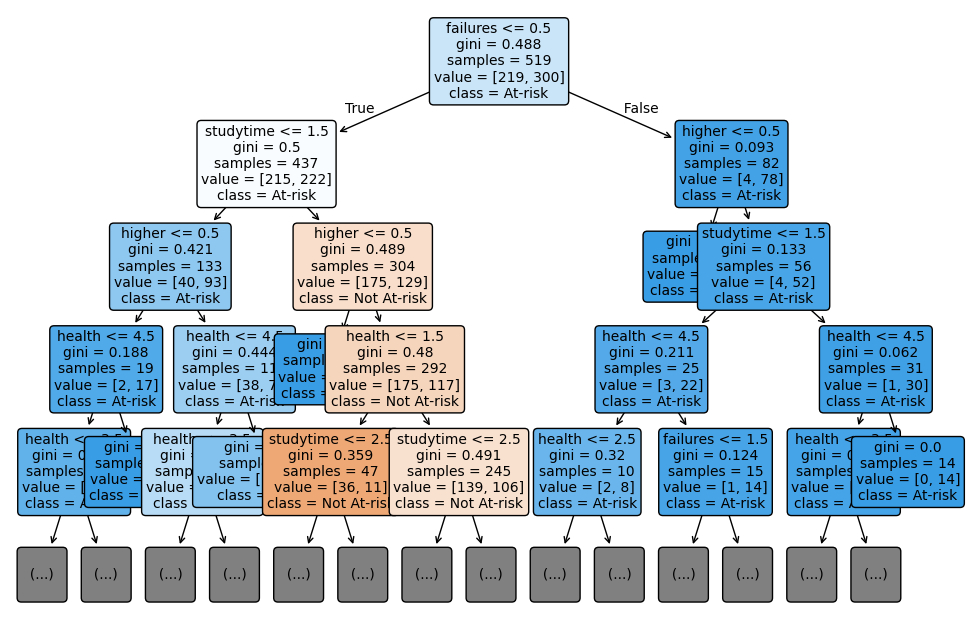

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Not At-risk", "At-risk"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=4
)

plt.show()

Support Vector Machine

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.5692307692307692
Precision: 0.6491228070175439
Recall: 0.5068493150684932
F1-score: 0.5692307692307692

Confusion Matrix:
[[37 20]
 [36 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.65      0.57        57
           1       0.65      0.51      0.57        73

    accuracy                           0.57       130
   macro avg       0.58      0.58      0.57       130
weighted avg       0.59      0.57      0.57       130



# 16 Model Comparison

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Support Vector Machine"
    ],
    "Accuracy": [
        logistic_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        logistic_precision,
        dt_precision,
        svm_precision
    ],
    "Recall": [
        logistic_recall,
        dt_recall,
        svm_recall
    ],
    "F1-score": [
        logistic_f1,
        dt_f1,
        svm_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.669231,0.714286,0.684932,0.699301
1,Decision Tree,0.607692,0.729167,0.479452,0.578512
2,Support Vector Machine,0.569231,0.649123,0.506849,0.569231


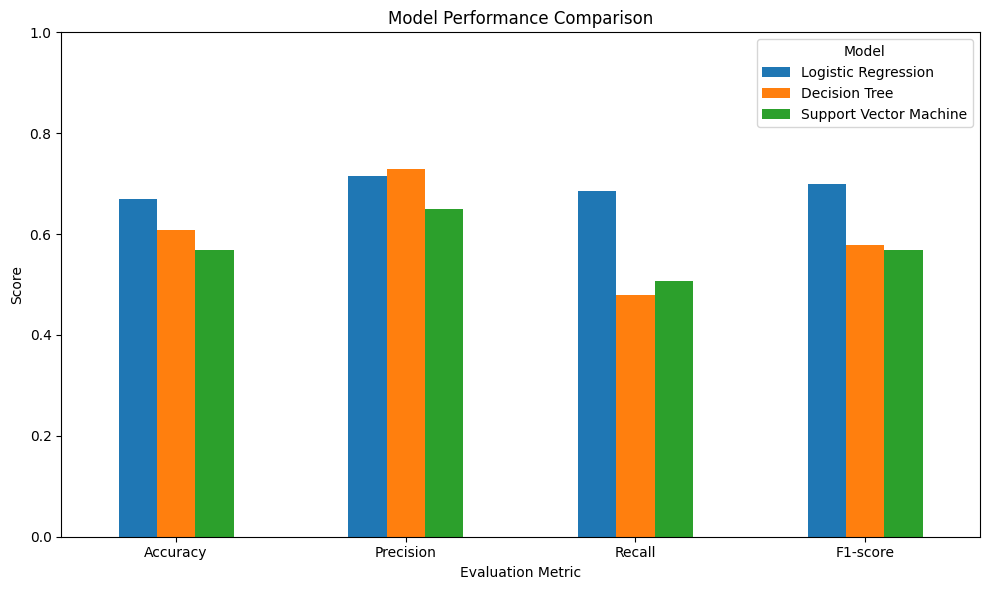

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

comparison.set_index("Model")[metrics].T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Model Comparison Summary

Logistic Regression achieved the highest Accuracy, Recall, and F1-score among the three models, showing the best overall balance in identifying at-risk students.

Decision Tree achieved the highest Precision, meaning its positive predictions were relatively reliable. However, its lower Recall indicates that it failed to identify many students who were actually at risk.

Support Vector Machine provided an alternative classification approach, but its overall performance was lower than Logistic Regression across most evaluation metrics.

Since the main objective of this project is to identify at-risk students as early as possible, Recall is particularly important. Therefore, Logistic Regression is considered the most suitable model for this project.

# 17 Business Insights

- The predictive model demonstrates that it is feasible to identify at-risk students before the end of the semester.

- Logistic Regression achieved the best overall performance among the evaluated models, providing a balanced trade-off between Accuracy, Recall, and F1-score.

- Early identification enables schools to allocate educational resources more effectively and intervene before students' academic performance declines further.

- Although the current model provides useful predictions, future improvements may be achieved through feature engineering, hyperparameter tuning, and additional relevant data.

# 18 Recommendations

Based on the prediction results, schools should identify students classified as at-risk as early as possible.

Teachers should first communicate with students to understand the underlying causes of their academic difficulties, such as learning habits, family support, or personal challenges.

After identifying the causes, schools can provide appropriate support, including academic tutoring, counseling services, or personalized learning plans.

By intervening before the end of the semester, schools may improve students' learning outcomes and make better use of limited educational resources.

# 19 Executive Summary

## Business Problem

This project investigated whether historical student data can be used to identify at-risk students before the end of the semester, enabling schools to provide timely interventions and improve academic outcomes.

## Key Findings

EDA, correlation analysis, and linear regression identified previous failures, study time, and higher education intention as the most influential factors associated with academic performance. These findings were used to guide feature selection for predictive modeling.

## Model Performance

Three classification models were evaluated: Logistic Regression, Decision Tree, and Support Vector Machine (SVM). Logistic Regression achieved the best overall balance across Accuracy, Recall, and F1-score. Because early identification of at-risk students is the primary objective, Logistic Regression was selected as the recommended model.

## Business Recommendation

The proposed model can help schools identify students who may require additional academic support before the end of the semester. Teachers can then communicate with these students to understand the underlying causes of their academic difficulties and provide appropriate interventions, allowing educational resources to be allocated more effectively.